# SVM v5 -- Raw Data (No Filter)

Key difference vs v4: loads directly from raw CSV files without any filtering.
Matches paper SeNic methodology: 'No signal pre-processing procedures are conducted.'

## Imports

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
from tqdm import tqdm

from config import (
    RANDOM_SEED, N_CLASSES, MODELS_DIR, FIGURES_DIR,
    SAMPLING_RATE, N_CHANNELS, WINDOW_SIZE, STRIDE_SIZE,
    REST_TRANSITION_SEC,
    SUBJECTS_INTERDAY_LONG, SUBJECTS_INTERDAY_SHORT,
    SUBJECTS_FATIGUE, SUBJECTS_NON_FATIGUE,
    GESTURE_CLASSES,
)
from src.experiment_runner import TEST_SUBJECTS, TRAIN_SUBJECTS, META
from src.feature_extraction import extract_features_batch
from src.evaluation import measure_latency, print_latency

np.random.seed(RANDOM_SEED)

## Raw CSV Loader (No Filter)

In [2]:
def load_raw_csv_trial(csv_path, gesture_label):
    df = pd.read_csv(csv_path, header=None)
    signal = df.iloc[:, :N_CHANNELS].to_numpy(dtype=np.float32)
    n_skip = int(REST_TRANSITION_SEC * SAMPLING_RATE)
    if signal.shape[0] <= n_skip:
        return np.empty((0, N_CHANNELS, WINDOW_SIZE), dtype=np.float32), np.empty((0,), dtype=np.int64)
    signal = signal[n_skip:]
    if signal.shape[0] < WINDOW_SIZE:
        return np.empty((0, N_CHANNELS, WINDOW_SIZE), dtype=np.float32), np.empty((0,), dtype=np.int64)
    n_windows = (signal.shape[0] - WINDOW_SIZE) // STRIDE_SIZE + 1
    windows = np.stack([signal[i * STRIDE_SIZE:i * STRIDE_SIZE + WINDOW_SIZE] for i in range(n_windows)])
    windows = windows.transpose(0, 2, 1).astype(np.float32)
    labels = np.full(n_windows, gesture_label, dtype=np.int64)
    return windows, labels


def load_raw_from_csv(df, verbose=False):
    all_w, all_l = [], []
    iterator = tqdm(df.iterrows(), total=len(df), disable=not verbose, desc="Loading raw CSV")
    for _, row in iterator:
        try:
            w, l = load_raw_csv_trial(row["raw_file_path"], int(row["gesture_label"]))
            if w.shape[0] > 0:
                all_w.append(w)
                all_l.append(l)
        except Exception:
            continue
    X = np.concatenate(all_w, axis=0)
    y = np.concatenate(all_l, axis=0)
    return X, y


def featurize(X, scaler=None, fit=False):
    F = extract_features_batch(X)
    if fit:
        scaler = StandardScaler().fit(F)
    if scaler is not None:
        F = scaler.transform(F)
    return F, scaler

## Train

In [3]:
train_meta = META[
    (META["subject"].isin(TRAIN_SUBJECTS)) & (META["session"] == 0)
]
fatigue_train = META[
    (META["subject"].isin(SUBJECTS_FATIGUE)) & (META["position"].isin([0, 1]))
]
train_combined = pd.concat([train_meta, fatigue_train]).drop_duplicates()

X_train, y_train = load_raw_from_csv(train_combined, verbose=True)
F_train, scaler = featurize(X_train, fit=True)
print(f"Windows: {X_train.shape}, Features: {F_train.shape}")

MAX_SAMPLES = 80000
if len(F_train) > MAX_SAMPLES:
    idx = resample(np.arange(len(y_train)), n_samples=MAX_SAMPLES,
                   random_state=RANDOM_SEED, stratify=y_train)
    F_sub, y_sub = F_train[idx], y_train[idx]
    print(f"Subsampled to {MAX_SAMPLES}")
else:
    F_sub, y_sub = F_train, y_train

svm = SVC(kernel="linear", C=1.0, random_state=RANDOM_SEED)
svm.fit(F_sub, y_sub)
print(f"Trained: {svm.n_support_.sum()} support vectors")

Loading raw CSV: 100%|██████████| 5790/5790 [00:10<00:00, 557.27it/s]


Windows: (651972, 8, 50), Features: (651972, 152)
Subsampled to 80000
Trained: 74491 support vectors


## Per-subject Sanity Check (vs Paper >90%)

Per-subject models on raw data, session 0, position 0.
This should closely match the paper methodology.

In [4]:
per_subject_acc = {}
all_subjects = sorted(META[(META["session"] == 0)]["subject"].unique())

for subj in all_subjects:
    subj_df = META[
        (META["subject"] == subj) & (META["session"] == 0) & (META["position"] == 0)
    ]
    tr_df = subj_df[subj_df["repetition"].isin([0, 1])]
    te_df = subj_df[subj_df["repetition"] == 2]
    if len(tr_df) == 0 or len(te_df) == 0:
        continue

    X_tr, y_tr = load_raw_from_csv(tr_df)
    X_te, y_te = load_raw_from_csv(te_df)
    F_tr, sc = featurize(X_tr, fit=True)
    F_te, _ = featurize(X_te, sc)

    m = SVC(kernel="linear", C=1.0, random_state=RANDOM_SEED)
    m.fit(F_tr, y_tr)
    per_subject_acc[subj] = accuracy_score(y_te, m.predict(F_te))

accs = list(per_subject_acc.values())
print(f"Per-subject: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "#" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Per-subject: mean=0.7917, min=0.5758, max=0.9283

  h0  : 0.854 ##################################
  h1  : 0.576 #######################
  h10 : 0.891 ###################################
  h11 : 0.640 #########################
  h12 : 0.703 ############################
  h13 : 0.750 #############################
  h14 : 0.916 ####################################
  h15 : 0.838 #################################
  h16 : 0.809 ################################
  h17 : 0.696 ###########################
  h18 : 0.886 ###################################
  h19 : 0.822 ################################
  h2  : 0.771 ##############################
  h20 : 0.731 #############################
  h21 : 0.918 ####################################
  h22 : 0.726 #############################
  h23 : 0.860 ##################################
  h24 : 0.864 ##################################
  h25 : 0.819 ################################
  h26 : 0.597 #######################
  h27 : 0.702 ####################

## S1-S5 Zero-shot

In [5]:
def predict_zs(df):
    X, y = load_raw_from_csv(df)
    F, _ = featurize(X, scaler)
    return accuracy_score(y, svm.predict(F))

s1_test = META[
    (META["subject"].isin(TEST_SUBJECTS))
    & (META["session"] == 0) & (META["position"] == 0)
]
s1_zs = predict_zs(s1_test)

s2_test = META[
    (META["subject"].isin(TEST_SUBJECTS))
    & (META["session"] == 0) & (META["position"] > 0)
]
s2_zs = predict_zs(s2_test)

s3_test = META[
    (META["subject"].isin(TEST_SUBJECTS)) & (META["session"] == 0)
]
s3_zs = predict_zs(s3_test)

interday_train_subj = [
    s for s in SUBJECTS_INTERDAY_LONG + SUBJECTS_INTERDAY_SHORT
    if s in TRAIN_SUBJECTS
]
s4_test = META[
    (META["subject"].isin(interday_train_subj))
    & (META["session"] > 0) & (META["position"] == 0)
]
s4_zs = predict_zs(s4_test) if len(s4_test) > 0 else float("nan")

s5_test = META[
    (META["subject"].isin(SUBJECTS_FATIGUE)) & (META["position"] >= 2)
]
s5_zs = predict_zs(s5_test) if len(s5_test) > 0 else float("nan")

print("Zero-shot:")
print(f"  S1 Ideal:        {s1_zs:.4f}")
print(f"  S2 Shift:        {s2_zs:.4f}")
print(f"  S3 Inter-subj:   {s3_zs:.4f}")
print(f"  S4 Inter-day:    {s4_zs:.4f}")
print(f"  S5 Fatigue:      {s5_zs:.4f}")

Zero-shot:
  S1 Ideal:        0.5021
  S2 Shift:        0.2990
  S3 Inter-subj:   0.3174
  S4 Inter-day:    0.4373
  S5 Fatigue:      0.5218


## S1-S5 Calibrated

In [6]:
def calibrate_per_subject(test_df, cal_reps=(0, 1), test_rep=2,
                       p0_only=False):
    accs = []
    for subj in sorted(test_df["subject"].unique()):
        sdf = test_df[test_df["subject"] == subj]
        cal_df = sdf[sdf["repetition"].isin(cal_reps)]
        te_df = sdf[sdf["repetition"] == test_rep]
        if p0_only:
            cal_df = cal_df[cal_df["position"] == 0]
        if len(cal_df) == 0 or len(te_df) == 0:
            continue
        X_c, y_c = load_raw_from_csv(cal_df)
        X_t, y_t = load_raw_from_csv(te_df)
        F_c, _ = featurize(X_c, scaler)
        F_t, _ = featurize(X_t, scaler)
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, C=1.0)
        clf.fit(F_c, y_c)
        accs.append(accuracy_score(y_t, clf.predict(F_t)))
    return np.mean(accs) if accs else float("nan")


s1_cal = calibrate_per_subject(s1_test)
s2_cal = calibrate_per_subject(s2_test)
s3_cal = calibrate_per_subject(s3_test)

s4_accs = []
for subj in sorted(s4_test["subject"].unique()):
    sdf = s4_test[s4_test["subject"] == subj]
    for sess in sorted(sdf["session"].unique()):
        sess_df = sdf[sdf["session"] == sess]
        cal_df = sess_df[sess_df["repetition"].isin([0, 1])]
        te_df = sess_df[sess_df["repetition"] == 2]
        if len(cal_df) == 0 or len(te_df) == 0:
            continue
        X_c, y_c = load_raw_from_csv(cal_df)
        X_t, y_t = load_raw_from_csv(te_df)
        F_c, _ = featurize(X_c, scaler)
        F_t, _ = featurize(X_t, scaler)
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, C=1.0)
        clf.fit(F_c, y_c)
        s4_accs.append(accuracy_score(y_t, clf.predict(F_t)))
s4_cal = np.mean(s4_accs) if s4_accs else float("nan")

s5_accs = []
for subj in sorted(s5_test["subject"].unique()):
    sdf = META[(META["subject"] == subj)]
    cal_df = sdf[sdf["position"].isin([0, 1])]
    te_df = sdf[sdf["position"] >= 2]
    if len(cal_df) == 0 or len(te_df) == 0:
        continue
    X_c, y_c = load_raw_from_csv(cal_df)
    X_t, y_t = load_raw_from_csv(te_df)
    F_c, _ = featurize(X_c, scaler)
    F_t, _ = featurize(X_t, scaler)
    clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, C=1.0)
    clf.fit(F_c, y_c)
    s5_accs.append(accuracy_score(y_t, clf.predict(F_t)))
s5_cal = np.mean(s5_accs) if s5_accs else float("nan")

print("Calibrated:")
print(f"  S1 Ideal:        {s1_cal:.4f}")
print(f"  S2 Shift:        {s2_cal:.4f}")
print(f"  S3 Inter-subj:   {s3_cal:.4f}")
print(f"  S4 Inter-day:    {s4_cal:.4f}")
print(f"  S5 Fatigue:      {s5_cal:.4f}")

Calibrated:
  S1 Ideal:        0.7784
  S2 Shift:        0.5126
  S3 Inter-subj:   0.5073
  S4 Inter-day:    0.8396
  S5 Fatigue:      0.8803


## S6: Combined Factor

In [7]:
s6_test = META[
    (META["subject"].isin(TEST_SUBJECTS))
    & (META["session"] == 0) & (META["position"] > 0)
]
X_s6, y_s6 = load_raw_from_csv(s6_test)
F_s6, _ = featurize(X_s6, scaler)
s6_zs = accuracy_score(y_s6, svm.predict(F_s6))
print(f"S6 zero-shot: {s6_zs:.4f}")

s6_cal_accs = []
for subj in sorted(TEST_SUBJECTS):
    sdf = s6_test[s6_test["subject"] == subj]
    cal_df = sdf[sdf["repetition"].isin([0, 1])]
    te_df = sdf[sdf["repetition"] == 2]
    if len(cal_df) == 0 or len(te_df) == 0:
        continue
    X_c, y_c = load_raw_from_csv(cal_df)
    X_t, y_t = load_raw_from_csv(te_df)
    F_c, _ = featurize(X_c, scaler)
    F_t, _ = featurize(X_t, scaler)
    clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, C=1.0)
    clf.fit(F_c, y_c)
    acc = accuracy_score(y_t, clf.predict(F_t))
    s6_cal_accs.append(acc)
    print(f"  {subj}: {acc:.4f}")

s6_cal = np.mean(s6_cal_accs) if s6_cal_accs else float("nan")
print(f"S6 calibrated avg: {s6_cal:.4f}")

S6 zero-shot: 0.2990
  h16: 0.4686
  h17: 0.4976
  h22: 0.4755
  h24: 0.6830
  h3: 0.4504
  h7: 0.5006
S6 calibrated avg: 0.5126


## S7: Gradual Electrode Shift (h24-h29)

  Position  0: 0.3884
  Position  1: 0.4093
  Position  2: 0.4035
  Position  3: 0.3809
  Position  4: 0.3675
  Position  5: 0.3457
  Position  6: 0.3730
  Position  7: 0.3727
  Position  8: 0.3422
  Position  9: 0.3168
  Position 10: 0.2748

P0 baseline: 0.3884, Avg shifted: 0.3586, Degradation: 2.97%


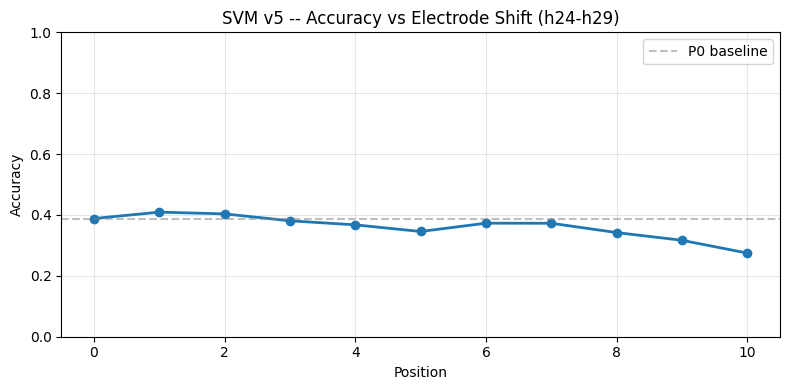

In [8]:
shift_subjects = [f"h{i}" for i in range(24, 30)]
shift_data = META[(META["subject"].isin(shift_subjects)) & (META["session"] == 0)]

s7_acc = {}
for pos in sorted(shift_data["position"].unique()):
    pos_df = shift_data[shift_data["position"] == pos]
    X_p, y_p = load_raw_from_csv(pos_df)
    F_p, _ = featurize(X_p, scaler)
    s7_acc[pos] = accuracy_score(y_p, svm.predict(F_p))
    print(f"  Position {pos:2d}: {s7_acc[pos]:.4f}")

baseline = s7_acc.get(0, 0)
avg_shifted = np.mean([s7_acc[p] for p in s7_acc if p > 0])
print(f"\nP0 baseline: {baseline:.4f}, Avg shifted: {avg_shifted:.4f}, "
      f"Degradation: {(baseline - avg_shifted) * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), "o-", linewidth=2)
plt.axhline(y=baseline, color="gray", linestyle="--", alpha=0.5, label="P0 baseline")
plt.xlabel("Position")
plt.ylabel("Accuracy")
plt.title("SVM v5 -- Accuracy vs Electrode Shift (h24-h29)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "svm_v5_shift_curve.png"), dpi=150)
plt.show()

## S8: Few-Shot Calibration Analysis

In [9]:
subset_s8 = META[(META["session"] == 0) & (META["subject"].isin(TEST_SUBJECTS))]

configs = [
    ("Zero-shot",        [],     False, 0),
    ("1 rep, p0 only",   [0],    True,  7),
    ("1 rep, all pos",   [0],    False, 77),
    ("2 rep, p0 only",   [0, 1], True,  14),
    ("2 rep, all pos",   [0, 1], False, 154),
]

s8_results = {}
for label, reps, p0_only, n_trials in configs:
    accs = []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8["subject"] == subj]
        if len(reps) == 0:
            X_t, y_t = load_raw_from_csv(sdf)
            F_t, _ = featurize(X_t, scaler)
            accs.append(accuracy_score(y_t, svm.predict(F_t)))
            continue
        if p0_only:
            cal_df = sdf[(sdf["repetition"].isin(reps)) & (sdf["position"] == 0)]
        else:
            cal_df = sdf[sdf["repetition"].isin(reps)]
        te_df = sdf[sdf["repetition"] == 2]
        if len(cal_df) == 0 or len(te_df) == 0:
            continue
        X_c, y_c = load_raw_from_csv(cal_df)
        X_t, y_t = load_raw_from_csv(te_df)
        F_c, _ = featurize(X_c, scaler)
        F_t, _ = featurize(X_t, scaler)
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, C=1.0)
        clf.fit(F_c, y_c)
        accs.append(accuracy_score(y_t, clf.predict(F_t)))
    s8_results[label] = np.mean(accs) if accs else float("nan")
    print(f"  {label:20s}: {s8_results[label]:.4f}  (~{n_trials} trials)")

  Zero-shot           : 0.3177  (~0 trials)
  1 rep, p0 only      : 0.2501  (~7 trials)
  1 rep, all pos      : 0.4698  (~77 trials)
  2 rep, p0 only      : 0.2712  (~14 trials)
  2 rep, all pos      : 0.5073  (~154 trials)


## Latency

In [10]:
sample_window = X_train[:1]

def svm_predict_single(x):
    f = extract_features_batch(x)
    f = scaler.transform(f)
    return svm.predict(f)

latency = measure_latency(svm_predict_single, sample_window, n_runs=500)
print_latency(latency, model_name="SVM v5 (feature extract + predict)")


Latency — SVM v5 (feature extract + predict)
  Mean:   3.00 ms
  Median: 2.73 ms
  P95:    3.58 ms
  <300ms: ✓


## Summary

In [11]:
print()
print("=" * 60)
print("  SVM v5 -- RESULTS")
print("=" * 60)
print(f"{'Scenario':<25s} {'Zero-shot':>10s} {'Calibrated':>12s} {'Delta':>10s}")
print("-" * 60)
pairs = [
    ("S1 Ideal", s1_zs, s1_cal),
    ("S2 Shift", s2_zs, s2_cal),
    ("S3 Inter-subject", s3_zs, s3_cal),
    ("S4 Inter-day", s4_zs, s4_cal),
    ("S5 Fatigue", s5_zs, s5_cal),
]
for name, zs, cal in pairs:
    d = cal - zs
    print(f"{name:<25s} {zs*100:>9.2f}% {cal*100:>11.2f}% {d*100:>+9.2f}%")
print(f"{'S6 Combined':<25s} {s6_zs*100:>9.2f}% {s6_cal*100:>11.2f}% {(s6_cal-s6_zs)*100:>+9.2f}%")
print(f"{'S7 Gradual (avg p1-10)':<25s} {avg_shifted*100:>9.2f}% {'--':>12s} {'--':>10s}")
for label, val in s8_results.items():
    if label == "Zero-shot":
        continue
    print(f"{'S8 ' + label:<25s} {'--':>10s} {val*100:>11.2f}% {'--':>10s}")
print("-" * 60)
print(f"Per-subject sanity check: mean={np.mean(list(per_subject_acc.values())):.4f}")
print(f"Latency (p95):           {latency['p95_ms']:.2f} ms")
print("=" * 60)


  SVM v5 -- RESULTS
Scenario                   Zero-shot   Calibrated      Delta
------------------------------------------------------------
S1 Ideal                      50.21%       77.84%    +27.63%
S2 Shift                      29.90%       51.26%    +21.36%
S3 Inter-subject              31.74%       50.73%    +18.99%
S4 Inter-day                  43.73%       83.96%    +40.23%
S5 Fatigue                    52.18%       88.03%    +35.85%
S6 Combined                   29.90%       51.26%    +21.36%
S7 Gradual (avg p1-10)        35.86%           --         --
S8 1 rep, p0 only                 --       25.01%         --
S8 1 rep, all pos                 --       46.98%         --
S8 2 rep, p0 only                 --       27.12%         --
S8 2 rep, all pos                 --       50.73%         --
------------------------------------------------------------
Per-subject sanity check: mean=0.7917
Latency (p95):           3.58 ms


## Save

In [12]:
joblib.dump({"model": svm, "scaler": scaler}, MODELS_DIR / "svm_v5.pkl")
print("Saved svm_v5.pkl")

Saved svm_v5.pkl
